# CRISP-DM: Predicting `is_fraud` (Part 2)

End-to-end pipeline: SQLite → denormalized features → sklearn → save model for deployment.

---

## Installation (run once)

In **Terminal**, **Anaconda Prompt**, or a notebook cell with `!pip`:

```bash
pip install pandas numpy scikit-learn matplotlib seaborn sqlalchemy joblib
```

**Optional — Supabase / Postgres URL from dashboard:**

```bash
pip install supabase psycopg2-binary python-dotenv
```

**Optional — extra tree libraries:**

```bash
pip install xgboost lightgbm
```

Use **Python 3.10+** if possible (matches most course materials).

---

## Notebook outline (CRISP-DM)

1. Business Understanding  
2. Data Understanding  
3. Data Preparation  
4. Modeling  
5. Evaluation  
6. Deployment + **website integration output** (see final section)

## 1. Business Understanding

**Problem:** Binary classification — predict whether an order is fraudulent (`is_fraud` = 1) or not (0).

**Success criteria (typical for fraud):** Precision/recall, F1, PR-AUC or ROC-AUC — not accuracy alone if classes are imbalanced.

**Stakeholders:** Fraud/risk, operations, customers affected by false positives.

*Edit this cell to match your write-up.*

## 2. Data Understanding — load & denormalize

We load `shop.db`, join `orders` with `customers`, `order_items` (+ `products`), and `shipments` into **one row per order** for ML.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import sqlite3

# Database path (same folder as assignment)
DB_PATH = Path(r"C:\Users\casey\Documents\OneDrive\IS jr\455\Chapter17Assignment\shop.db")
assert DB_PATH.exists(), f"Missing database: {DB_PATH}"

conn = sqlite3.connect(DB_PATH)

In [2]:
DENORMALIZED_SQL = """
SELECT
  o.order_id,
  o.customer_id,
  o.order_datetime,
  o.billing_zip,
  o.shipping_zip,
  o.shipping_state,
  o.payment_method,
  o.device_type,
  o.ip_country,
  o.promo_used,
  o.promo_code,
  o.order_subtotal,
  o.shipping_fee,
  o.tax_amount,
  o.order_total,
  o.risk_score,
  o.is_fraud,
  c.gender,
  c.city AS cust_city,
  c.state AS cust_state,
  c.zip_code AS cust_zip,
  c.customer_segment,
  c.loyalty_tier,
  c.is_active AS cust_is_active,
  oi.n_lines,
  oi.total_quantity,
  oi.sum_line_total,
  oi.n_distinct_products,
  oi.n_distinct_categories,
  s.carrier,
  s.shipping_method,
  s.distance_band,
  s.promised_days,
  s.actual_days,
  s.late_delivery
FROM orders o
LEFT JOIN customers c ON o.customer_id = c.customer_id
LEFT JOIN (
  SELECT
    oi.order_id,
    COUNT(*) AS n_lines,
    SUM(oi.quantity) AS total_quantity,
    SUM(oi.line_total) AS sum_line_total,
    COUNT(DISTINCT oi.product_id) AS n_distinct_products,
    COUNT(DISTINCT p.category) AS n_distinct_categories
  FROM order_items oi
  LEFT JOIN products p ON oi.product_id = p.product_id
  GROUP BY oi.order_id
) oi ON o.order_id = oi.order_id
LEFT JOIN shipments s ON o.order_id = s.order_id
"""

df = pd.read_sql_query(DENORMALIZED_SQL, conn)
conn.close()
df["order_datetime"] = pd.to_datetime(df["order_datetime"], errors="coerce")
df.shape, df["is_fraud"].value_counts()

((5000, 35),
 is_fraud
 0    4682
 1     318
 Name: count, dtype: int64)

In [3]:
df.head()

,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,...,total_quantity,sum_line_total,n_distinct_products,n_distinct_categories,carrier,shipping_method,distance_band,promised_days,actual_days,late_delivery
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,...,9,662.95,5,4,UPS,expedited,regional,3,5,1
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,...,7,862.92,5,3,FedEx,expedited,local,2,3,1
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,...,5,796.09,3,2,FedEx,expedited,national,4,8,1
3,4,1,2025-11-06 18:21:19,28289,28289,CO,bank,mobile,US,1,...,1,137.60,1,1,UPS,standard,regional,6,6,0
4,5,1,2025-11-30 05:34:15,28289,28289,CO,card,mobile,CA,0,...,1,17.07,1,1,USPS,standard,regional,6,7,1


In [4]:
df.info()
df.isna().sum().sort_values(ascending=False).head(20)

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               5000 non-null   int64         
 1   customer_id            5000 non-null   int64         
 2   order_datetime         5000 non-null   datetime64[us]
 3   billing_zip            5000 non-null   str           
 4   shipping_zip           5000 non-null   str           
 5   shipping_state         5000 non-null   str           
 6   payment_method         5000 non-null   str           
 7   device_type            5000 non-null   str           
 8   ip_country             5000 non-null   str           
 9   promo_used             5000 non-null   int64         
 10  promo_code             1261 non-null   str           
 11  order_subtotal         5000 non-null   float64       
 12  shipping_fee           5000 non-null   float64       
 13  tax_amount    

promo_code        3739
customer_id          0
order_id             0
order_datetime       0
billing_zip          0
shipping_state       0
shipping_zip         0
payment_method       0
device_type          0
ip_country           0
promo_used           0
order_subtotal       0
shipping_fee         0
tax_amount           0
order_total          0
risk_score           0
is_fraud             0
gender               0
cust_city            0
cust_state           0
dtype: int64

### EDA plots (Ch. 6 & 8)

Add histograms, boxplots, and fraud rate by category. *Extend below.*

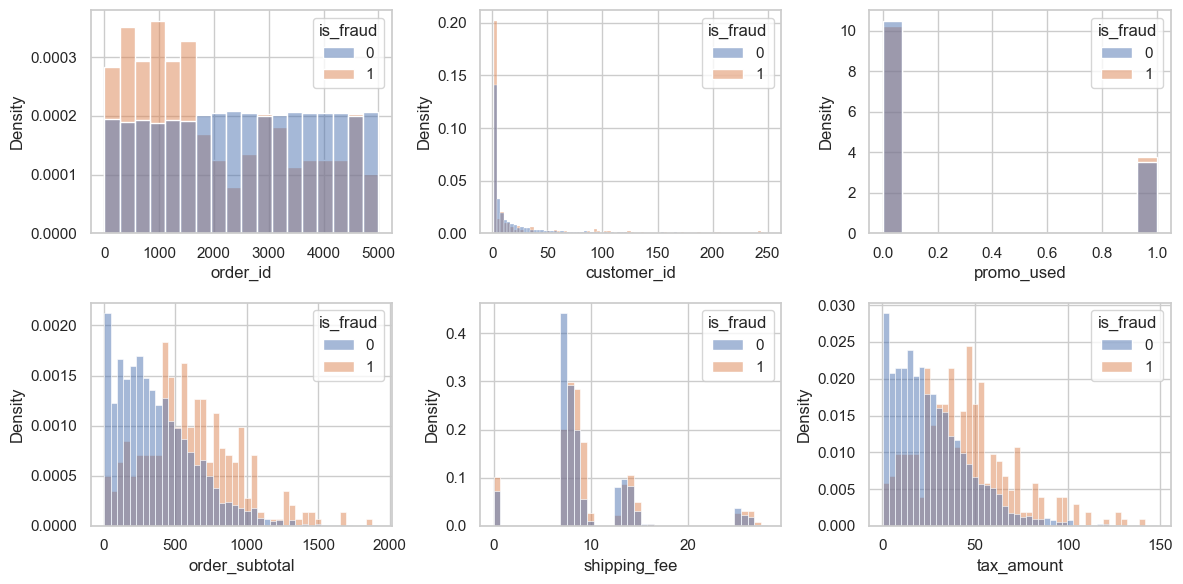

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
num_cols = df.select_dtypes(include=[np.number]).columns.drop("is_fraud", errors="ignore")
if len(num_cols) > 0:
    n = min(6, len(num_cols))
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.ravel()
    for i, col in enumerate(num_cols[:6]):
        sns.histplot(data=df, x=col, hue="is_fraud", stat="density", common_norm=False, ax=axes[i])
    for j in range(n, 6):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

## 3. Data Preparation — features, split, `Pipeline`

- Drop identifiers and **leakage** columns you decide not to use (e.g. `risk_score` if it is derived post-fraud).  
- Add time features from `order_datetime`.  
- Use **stratified** split on `is_fraud`.

In [ ]:
FEATURE_DROPS = ["order_id", "is_fraud"]
# Optional: drop leakage — uncomment if your instructor agrees `risk_score` is not usable at prediction time:
# FEATURE_DROPS.append("risk_score")

X = df.drop(columns=[c for c in FEATURE_DROPS if c in df.columns])
y = df["is_fraud"].astype(int)

X = X.copy()
X["order_hour"] = X["order_datetime"].dt.hour
X["order_dow"] = X["order_datetime"].dt.dayofweek
X = X.drop(columns=["order_datetime"])

cat_cols = X.select_dtypes(include=["str", "object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]
len(cat_cols), len(num_cols)

C:\Users\casey\AppData\Local\Temp\ipykernel_107864\2287551088.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


(16, 18)

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_pipe = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)
categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ]
)

model = HistGradientBoostingClassifier(random_state=42)
full_pipeline = Pipeline(
    steps=[("preprocess", preprocess), ("model", model)]
)

full_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## 4. Modeling

Above uses **HistGradientBoosting** inside a full `Pipeline`. Add **RandomForest**, **LogisticRegression**, or **XGBoost** in new cells; compare on validation CV (Ch. 15).

## 5. Evaluation

Tune with `GridSearchCV` / `RandomizedSearchCV` on training data; **feature selection** (Ch. 16) optional. Final metrics on `X_test` once.

In [8]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = full_pipeline.predict(X_test)
y_proba = full_pipeline.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0     0.9687    0.9915    0.9799       936
           1     0.8095    0.5312    0.6415        64

    accuracy                         0.9620      1000
   macro avg     0.8891    0.7614    0.8107      1000
weighted avg     0.9585    0.9620    0.9583      1000

ROC-AUC: 0.9660957532051282


## 6. Deployment — save model & website integration

### What you persist

- **One file** (e.g. `fraud_pipeline.joblib`) containing the **entire fitted `Pipeline`** (preprocessing + model).  
- Your app loads it with `joblib.load` and calls **`predict`** / **`predict_proba`** on a **single row** (or batch) DataFrame with **the same column names** as `X` before training (raw features, not one-hot columns).

### What the website / API receives **from** the pipeline

After a checkout or review request, your backend builds a **feature dict or row** matching training columns, wraps it in `pd.DataFrame([row])`, then:

| Output | Type | Meaning |
|--------|------|--------|
| `predict()` | `array` of `{0,1}` | Predicted class: **0 = not fraud**, **1 = fraud** |
| `predict_proba()` | `array` shape `(n_samples, 2)` | `[P(not fraud), P(fraud)]` for class order `classes_` |

Example **JSON your API can return** to the frontend:

```json
{
  "is_fraud": false,
  "fraud_probability": 0.08,
  "not_fraud_probability": 0.92,
  "model_version": "fraud_pipeline.joblib"
}
```

Map `fraud_probability` from `predict_proba[:, 1]` (index of class `1` in `pipeline.named_steps['model'].classes_`).

### What the website must **send** (input contract)

Same features as training `X` (e.g. `customer_id`, `billing_zip`, … `order_hour`, `order_dow` without `order_datetime` if you engineered time in the app the same way). **Do not** send `is_fraud` for scoring.

---

Optional: store **Supabase** Postgres URL in `.env` and load features from a table; scoring still runs the same `joblib` pipeline in Python.

In [9]:
import joblib

MODEL_PATH = Path(r"C:\Users\casey\Documents\OneDrive\IS jr\455\Chapter17Assignment\fraud_order_pipeline.joblib")
joblib.dump(full_pipeline, MODEL_PATH)
print("Saved:", MODEL_PATH.resolve())

Saved: C:\Users\casey\Documents\OneDrive\IS jr\455\Chapter17Assignment\fraud_order_pipeline.joblib


In [10]:
loaded = joblib.load(MODEL_PATH)
sample = X_test.iloc[:0].copy()
sample = pd.concat([sample, X_test.iloc[[0]]], ignore_index=True)
proba = loaded.predict_proba(sample)[0]
clf = loaded.named_steps["model"]
classes = clf.classes_
out = {
    "predicted_class": int(loaded.predict(sample)[0]),
    "class_order": classes.tolist(),
    "probabilities": {int(classes[i]): float(proba[i]) for i in range(len(classes))},
}
out

{'predicted_class': 0,
 'class_order': [0, 1],
 'probabilities': {0: 0.9999607389383653, 1: 3.926106163460279e-05}}